# 📚 Dataset: Tiny Shakespeare
Originally from Andrej Karpathy's *'The Unreasonable Effectiveness of Recurrent Neural Networks'*.
A single text file containing the works of Shakespeare — perfect for character-level language modeling.

## Step 1: Download the data

In [1]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
print('Downloaded!')

Downloaded!


## Step 2: Load and inspect the raw text

In [2]:
with open('input.txt', 'r') as f:
    data = f.read()

print(f'Total characters: {len(data):,}')
print()
print('--- First 500 characters ---')
print(data[:500])

Total characters: 1,115,394

--- First 500 characters ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## Step 3: Build the vocabulary
We do **character-level** tokenization — each unique character in the text becomes a token.
This gives us a small, interpretable vocabulary.

In [3]:
# get unique characters
tokens = sorted(list(set(data)))
vocab_size = len(tokens)

# build lookup tables
char_to_int = {char: i for i, char in enumerate(tokens)}
int_to_char = {i: char for i, char in enumerate(tokens)}

print(f'Vocabulary size: {vocab_size}')
print()
print('Vocabulary:')
print(repr(''.join(tokens)))

Vocabulary size: 65

Vocabulary:
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


## Step 4: Encode and decode
**Encoding**: convert a string of characters → a sequence of integers

**Decoding**: convert a sequence of integers → back to a string

In [4]:
import torch

def encode(text):
    """Convert a string to a tensor of integer token ids."""
    return torch.tensor([char_to_int[c] for c in text], dtype=torch.long)

def decode(tokens):
    """Convert a tensor of integer token ids back to a string."""
    return ''.join([int_to_char[t.item()] for t in tokens])

# try it out
example = 'How you doin?'
encoded = encode(example)
decoded = decode(encoded)

print(f'Original:  {example}')
print(f'Encoded:   {encoded}')
print(f'Decoded:   {decoded}')
print(f'Shape:     {encoded.shape}  ← one integer per character')

Original:  How you doin?
Encoded:   tensor([20, 53, 61,  1, 63, 53, 59,  1, 42, 53, 47, 52, 12])
Decoded:   How you doin?
Shape:     torch.Size([13])  ← one integer per character


---
# 🔍 Single Head Attention

The data matrix has shape `(sequence_length, embedding_dim)` — one row per token.

We project it three times to get **Q** (query), **K** (key), **V** (value), each shape `(L, E)`.

Then:
$$A = \text{softmax}\!\left(\frac{QK^T}{\sqrt{E}}\right), \qquad \text{output} = AV$$

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ── Hyperparameters ─────────────────────────────────────────────────────────
embedding_dim = 4        # matches the slides

# ── Token embedding layer ────────────────────────────────────────────────────
token_embedding_layer = nn.Embedding(vocab_size, embedding_dim)

# ── Embed our example sentence ───────────────────────────────────────────────
example   = 'How you doin?'
token_ids = encode(example)                   # shape: (13,)
x         = token_embedding_layer(token_ids)  # shape: (13, 4)  — the data matrix

L, E = x.shape
print(f'Data matrix shape: {x.shape}  →  L={L} tokens, E={E}-dim embeddings')

Data matrix shape: torch.Size([13, 4])  →  L=13 tokens, E=4-dim embeddings


In [6]:
# ── Weight matrices W_Q, W_K, W_V  (each E × E) ─────────────────────────────
W_Q = nn.Linear(E, E, bias=False)
W_K = nn.Linear(E, E, bias=False)
W_V = nn.Linear(E, E, bias=False)

Q = W_Q(x)   # (L, E)
K = W_K(x)   # (L, E)
V = W_V(x)   # (L, E)

print(f'Q shape: {Q.shape}')   # (13, 12)
print(f'K shape: {K.shape}')   # (13, 12)
print(f'V shape: {V.shape}')   # (13, 12)

Q shape: torch.Size([13, 4])
K shape: torch.Size([13, 4])
V shape: torch.Size([13, 4])


In [ ]:
# ── Attention scores: QKᵀ scaled by 1/√E ────────────────────────────────────
scores = (Q @ K.T) / math.sqrt(E)   # (L, L)

# ── Softmax → attention weights (rows sum to 1) ──────────────────────────────
A = F.softmax(scores, dim=-1)        # (L, L)

# ── Weighted sum of values ────────────────────────────────────────────────────
output = A @ V                       # (L, E)

print(f'Attention matrix A shape : {A.shape}')       # (13, 13)
print(f'Output shape             : {output.shape}')  # (13, 12)
print(f'\nAttention weights for first token (row 0 of A):')
print(A[0].detach().round(decimals=3))
print(f'Sum: {A[0].detach().sum():.4f}')

Attention matrix A shape : torch.Size([13, 13])
Output shape             : torch.Size([13, 4])

Attention weights for first token (row 0 of A):
tensor([0.0840, 0.0840, 0.0800, 0.0720, 0.0830, 0.0840, 0.0710, 0.0720, 0.0760,
        0.0840, 0.0600, 0.0790, 0.0730])
Sum: 1.0000


In [8]:
class SingleHeadAttention(nn.Module):
    """Single-head self-attention."""

    def __init__(self, embedding_dim):
        super().__init__()
        self.scale = math.sqrt(embedding_dim)
        self.W_Q   = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.W_K   = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.W_V   = nn.Linear(embedding_dim, embedding_dim, bias=False)

    def forward(self, x):
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        A = F.softmax((Q @ K.T) / self.scale, dim=-1)
        return A @ V


sha = SingleHeadAttention(embedding_dim=E)
out = sha(x)
print(f'Input shape  : {x.shape}')    # (13, 12)
print(f'Output shape : {out.shape}')  # (13, 12)

Input shape  : torch.Size([13, 4])
Output shape : torch.Size([13, 4])


In [9]:
# ── Re-embed with a larger embedding dim for multi-head ───────────────────────
# We need embedding_dim divisible by num_heads=4, so we use 12
embedding_dim = 12
token_embedding_layer = nn.Embedding(vocab_size, embedding_dim)
x         = token_embedding_layer(token_ids)   # (13, 12)
x_batched = x.unsqueeze(0)                     # (1, 13, 12)

L, E = x.shape
print(f'Data matrix shape for MHA: {x.shape}  →  L={L} tokens, E={E}-dim embeddings')

Data matrix shape for MHA: torch.Size([13, 12])  →  L=13 tokens, E=12-dim embeddings


---
# 🧠 Multi-Head Attention

Instead of one set of Q/K/V projections, we run **h independent attention heads in parallel**.

Each head can learn to attend to different kinds of relationships simultaneously.  
Their outputs are **concatenated** and mixed through a final projection `W_O`:

$$\text{MultiHead}(x) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W_O$$

In [ ]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention."""

    def __init__(self, embedding_dim, num_heads):
        super().__init__()
        assert embedding_dim % num_heads == 0, \
            'embedding_dim must be divisible by num_heads'

        self.num_heads = num_heads
        self.head_dim  = embedding_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)

        # One big projection for all heads — we split into Q, K, V afterwards
        self.W_QKV = nn.Linear(embedding_dim, 3 * embedding_dim, bias=False)

        # Final output projection W_O
        self.W_O = nn.Linear(embedding_dim, embedding_dim, bias=False)

    def forward(self, x):
        B, L, E = x.shape
        h, d    = self.num_heads, self.head_dim

        # ── Project → Q, K, V ────────────────────────────────────────────────
        Q, K, V = self.W_QKV(x).split(E, dim=-1)   # each (B, L, E)

        # ── Reshape: (B, L, E) → (B, h, L, d) ───────────────────────────────
        Q = Q.view(B, L, h, d).transpose(1, 2)      # (B, h, L, d)
        K = K.view(B, L, h, d).transpose(1, 2)
        V = V.view(B, L, h, d).transpose(1, 2)

        # ── Scaled dot-product per head ───────────────────────────────────────
        A   = F.softmax((Q @ K.transpose(-2, -1)) / self.scale, dim=-1)  # (B, h, L, L)
        out = A @ V                                                        # (B, h, L, d)

        # ── Concatenate heads: (B, h, L, d) → (B, L, E) ─────────────────────
        out = out.transpose(1, 2).contiguous().view(B, L, E)

        return self.W_O(out)   # (B, L, E)


mha       = MultiHeadAttention(embedding_dim=E, num_heads=3)
x_batched = x.unsqueeze(0)    # add batch dim: (1, 13, 12)
out       = mha(x_batched)

print(f'Input shape  : {x_batched.shape}')   # (1, 13, 12)
print(f'Output shape : {out.shape}')          # (1, 13, 12)
print(f'\nnum_heads={mha.num_heads}, head_dim={mha.head_dim}')

Input shape  : torch.Size([1, 13, 12])
Output shape : torch.Size([1, 13, 12])

num_heads=3, head_dim=4


---
# 🔀 Attention is order-agnostic (without positional encoding)

Shuffle the tokens → the output rows shuffle in exactly the same way.  
The model has no sense of *which token came first* unless we inject that information.

In [11]:
perm = torch.randperm(L)

print(f"Original text : {decode(token_ids)}")
print(f"Shuffled text : {decode(token_ids[perm])}")

# find where 'w' is in original and shuffled
orig_pos = 2  # 'w' is always at position 2 in "How you doin?"
shuf_pos = (perm == 2).nonzero().item()  # where did 'w' end up after shuffle?

print(f"\n'w' is at position {orig_pos} in original text")
print(f"'w' is at position {shuf_pos} in shuffled text")

# ── Run MHA on original and shuffled ─────────────────────────────────────────
x_shuffled = x_batched[:, perm, :]

with torch.no_grad():
    out_orig = mha(x_batched)
    out_shuf = mha(x_shuffled)

# ── Directly compare the 'w' embedding in both outputs ───────────────────────
print(f"\nPost-attention embedding of 'w' at position {orig_pos} in original : {out_orig[0, orig_pos].detach()}")
print(f"Post-attention embedding of 'w' at position {shuf_pos} in shuffled : {out_shuf[0, shuf_pos].detach()}")
print(f"\nAre they the same? {torch.allclose(out_orig[0, orig_pos], out_shuf[0, shuf_pos], atol=1e-5)}")
print("The embedding of 'w' is the same regardless of where it sits")

Original text : How you doin?
Shuffled text : Hu? nyoi oowd

'w' is at position 2 in original text
'w' is at position 11 in shuffled text

Post-attention embedding of 'w' at position 2 in original : tensor([ 0.1182,  0.0329,  0.0090,  0.0108, -0.0704,  0.0241, -0.0832,  0.0104,
        -0.0207, -0.1179,  0.0206,  0.0159])
Post-attention embedding of 'w' at position 11 in shuffled : tensor([ 0.1182,  0.0329,  0.0090,  0.0108, -0.0704,  0.0241, -0.0832,  0.0104,
        -0.0207, -0.1179,  0.0206,  0.0159])

Are they the same? True
The embedding of 'w' is the same regardless of where it sits


In [12]:
# ── Add learned positional encoding ──────────────────────────────────────────
positional_encoding = nn.Embedding(L, 12)  # must match MHA embedding dim
positions = torch.arange(L)

x_pos      = x_batched + positional_encoding(positions).unsqueeze(0)
x_shuf_pos = x_shuffled + positional_encoding(positions).unsqueeze(0)

with torch.no_grad():
    out_orig_pos = mha(x_pos)
    out_shuf_pos = mha(x_shuf_pos)

# ── Directly compare the 'w' embedding in both outputs ───────────────────────
print(f"Original text : {decode(token_ids)}")
print(f"Shuffled text : {decode(token_ids[perm])}")

print(f"\n'w' is at position {orig_pos} in original text")
print(f"'w' is at position {shuf_pos} in shuffled text")

print(f"\nPost-attention embedding of 'w' at position {orig_pos} in original : {out_orig_pos[0, orig_pos].detach()}")
print(f"Post-attention embedding of 'w' at position {shuf_pos} in shuffled : {out_shuf_pos[0, shuf_pos].detach()}")
print(f"\nAre they the same? {torch.allclose(out_orig_pos[0, orig_pos], out_shuf_pos[0, shuf_pos], atol=1e-5)}")
print("→ With positional encoding, token order now affects the output — 'w' has a different embedding depending on where it sits")

Original text : How you doin?
Shuffled text : Hu? nyoi oowd

'w' is at position 2 in original text
'w' is at position 11 in shuffled text

Post-attention embedding of 'w' at position 2 in original : tensor([ 0.1778,  0.1621,  0.1201, -0.0192, -0.1284, -0.0032, -0.0039, -0.0246,
        -0.0209, -0.1598,  0.2000, -0.0561])
Post-attention embedding of 'w' at position 11 in shuffled : tensor([ 0.1798,  0.2764,  0.1779, -0.0286, -0.0945, -0.0226, -0.0145, -0.0858,
         0.0108, -0.2505,  0.2955, -0.0684])

Are they the same? False
→ With positional encoding, token order now affects the output — 'w' has a different embedding depending on where it sits


---
# ⚠️ Causal Masking

For **next-token prediction** token `i` must not attend to any future token `j > i`.

We manually set the upper-triangle of the score matrix to `-inf` before the softmax —  
so those entries become exactly `0` after it.

In [13]:
import matplotlib.pyplot as plt

# ── Re-embed with E=4 to match single head section ───────────────────────────
E = 4
token_embedding_layer = nn.Embedding(vocab_size, E)
x = token_embedding_layer(token_ids)   # (13, 4)

W_Q = nn.Linear(E, E, bias=False)
W_K = nn.Linear(E, E, bias=False)

with torch.no_grad():
    Q = W_Q(x)
    K = W_K(x)
    scores = (Q @ K.T) / math.sqrt(E)   # (L, L)

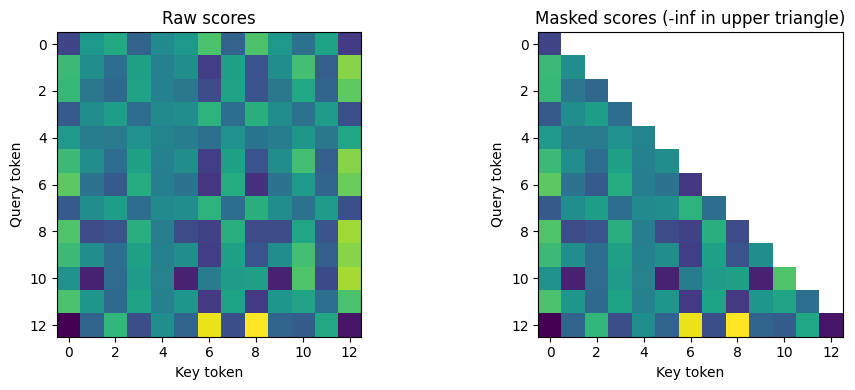

In [14]:
# ── Build a lower-triangular mask ────────────────────────────────────────────
causal_mask = torch.tril(torch.ones(L, L)).bool()   # True = allowed
# ── Set future positions to -inf ─────────────────────────────────────────────
masked_scores = scores.masked_fill(~causal_mask, float('-inf'))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(scores.detach().numpy(), cmap='viridis')
axes[0].set_title('Raw scores')
axes[0].set_xlabel('Key token')
axes[0].set_ylabel('Query token')

axes[1].imshow(masked_scores.detach().numpy(), cmap='viridis')
axes[1].set_title('Masked scores (-inf in upper triangle)')
axes[1].set_xlabel('Key token')
axes[1].set_ylabel('Query token')

plt.tight_layout()
plt.show()

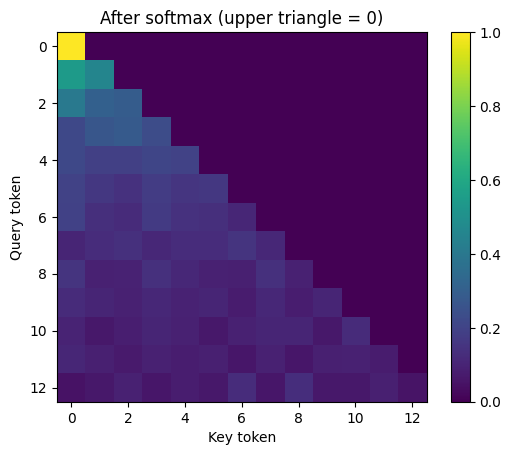

In [15]:
A_causal = F.softmax(masked_scores, dim=-1)

plt.imshow(A_causal.detach().numpy(), cmap='viridis')
plt.title('After softmax (upper triangle = 0)')
plt.xlabel('Key token')
plt.ylabel('Query token')
plt.colorbar()
plt.show()

---
# 🧱 Layer Norm

Before feeding into attention or MLP, we normalize each token's embedding to have zero mean and unit variance — then apply a learnable scale and shift.

In [16]:
class LayerNorm(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(embedding_dim))   # learnable scale
        self.bias   = nn.Parameter(torch.zeros(embedding_dim))  # learnable shift

    def forward(self, x):
        # subtract mean and divide by std across the embedding dimension
        mean = x.mean(dim=-1, keepdim=True)
        std  = x.std(dim=-1, keepdim=True)
        x    = (x - mean) / (std + 1e-5)
        # learnable scale and shift per embedding dimension
        return self.weight * x + self.bias

# ── Try it out ────────────────────────────────────────────────────────────────
ln  = LayerNorm(embedding_dim=12)
out = ln(x_batched)
print(f'Input shape  : {x_batched.shape}')
print(f'Output shape : {out.shape}')

Input shape  : torch.Size([1, 13, 12])
Output shape : torch.Size([1, 13, 12])


---
# 🔁 MLP

Applied to each token independently after attention. Two linear layers with a GELU non-linearity in between — expands the embedding dim by a factor of 4 then projects back.

In [17]:
class MLP(nn.Module):
    def __init__(self, embedding_dim, mlp_ratio=4):
        super().__init__()
        self.layer_1 = nn.Linear(embedding_dim, mlp_ratio * embedding_dim)
        self.gelu    = nn.GELU()
        self.layer_2 = nn.Linear(mlp_ratio * embedding_dim, embedding_dim)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.gelu(x)
        x = self.layer_2(x)
        return x


# ── Try it out ────────────────────────────────────────────────────────────────
mlp = MLP(embedding_dim=12)
out = mlp(x_batched)
print(f'Input shape  : {x_batched.shape}')
print(f'Output shape : {out.shape}')

Input shape  : torch.Size([1, 13, 12])
Output shape : torch.Size([1, 13, 12])


---
# 🔷 Transformer Block

One transformer block = LayerNorm + MultiHeadAttention + residual, followed by LayerNorm + MLP + residual.

$$x = x + \text{Attention}(\text{LayerNorm}(x))$$
$$x = x + \text{MLP}(\text{LayerNorm}(x))$$

In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads, context_length):
        super().__init__()
        assert embedding_dim % num_heads == 0

        self.num_heads = num_heads
        self.head_dim  = embedding_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)

        self.W_QKV = nn.Linear(embedding_dim, 3 * embedding_dim, bias=False)
        self.W_O   = nn.Linear(embedding_dim, embedding_dim, bias=False)

        self.register_buffer(
            'causal_mask',
            torch.tril(torch.ones(context_length, context_length)).bool()
        )

    def forward(self, x):
        B, L, E = x.shape
        h, d    = self.num_heads, self.head_dim

        Q, K, V = self.W_QKV(x).split(E, dim=-1)

        Q = Q.view(B, L, h, d).transpose(1, 2)
        K = K.view(B, L, h, d).transpose(1, 2)
        V = V.view(B, L, h, d).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / self.scale
        scores = scores.masked_fill(~self.causal_mask[:L, :L], float('-inf'))
        A      = F.softmax(scores, dim=-1)
        out    = A @ V

        out = out.transpose(1, 2).contiguous().view(B, L, E)
        return self.W_O(out)



class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, context_length):
        super().__init__()
        self.ln_1 = LayerNorm(embedding_dim)
        self.attn = MultiHeadAttention(embedding_dim, num_heads, context_length)
        self.ln_2 = LayerNorm(embedding_dim)
        self.mlp  = MLP(embedding_dim)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


# ── Try it out ────────────────────────────────────────────────────────────────
block = TransformerBlock(embedding_dim=12, num_heads=4, context_length=256)
out   = block(x_batched)
print(f'Input shape  : {x_batched.shape}')
print(f'Output shape : {out.shape}')

Input shape  : torch.Size([1, 13, 12])
Output shape : torch.Size([1, 13, 12])


---
# 🌐 Language Model

A stack of transformer blocks, with a final linear layer + softmax to produce a probability distribution over the vocabulary at each position.

In [19]:

class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, context_length):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding = nn.Embedding(context_length, embedding_dim)
        self.blocks             = nn.ModuleList([
            TransformerBlock(embedding_dim, num_heads, context_length) for _ in range(num_layers)
        ])
        self.ln_final = LayerNorm(embedding_dim)
        self.output   = nn.Linear(embedding_dim, vocab_size)

    def forward(self, token_ids):
        B, L      = token_ids.shape
        positions = torch.arange(L, device=token_ids.device)
        x         = self.token_embedding(token_ids) + self.position_embedding(positions)
        for block in self.blocks:
            x = block(x)
        x      = self.ln_final(x)
        logits = self.output(x)
        return logits


# ── Try it out ────────────────────────────────────────────────────────────────
model  = LanguageModel(
    vocab_size     = vocab_size,
    embedding_dim  = 12,
    num_heads      = 4,
    num_layers     = 4,
    context_length = 256
)

token_ids_batched = token_ids.unsqueeze(0)   # (1, 13)
logits = model(token_ids_batched)

print(f'Input shape  : {token_ids_batched.shape}')   # (1, 13)
print(f'Output shape : {logits.shape}')               # (1, 13, 65)
print(f'\nAt each of the {token_ids_batched.shape[1]} positions the model outputs a distribution over {vocab_size} characters')

Input shape  : torch.Size([1, 13])
Output shape : torch.Size([1, 13, 65])

At each of the 13 positions the model outputs a distribution over 65 characters


---
# 🏋️ Training

Using device: cuda
step    0 | train loss 4.3887 | val loss 3.7619
step   50 | train loss 2.5331 | val loss 2.5118
step  100 | train loss 2.4662 | val loss 2.5056
step  150 | train loss 2.4576 | val loss 2.4688
step  200 | train loss 2.3957 | val loss 2.4531
step  250 | train loss 2.3522 | val loss 2.3740
step  300 | train loss 2.2102 | val loss 2.3303
step  350 | train loss 2.1404 | val loss 2.1672
step  400 | train loss 2.0605 | val loss 2.1275
step  450 | train loss 2.0433 | val loss 2.0917
step  500 | train loss 1.8957 | val loss 2.0338
step  550 | train loss 1.8517 | val loss 1.9492
step  600 | train loss 1.8300 | val loss 1.9364
step  650 | train loss 1.7329 | val loss 1.8630
step  700 | train loss 1.7142 | val loss 1.8482
step  750 | train loss 1.6751 | val loss 1.8251
step  800 | train loss 1.6759 | val loss 1.8500
step  850 | train loss 1.6459 | val loss 1.6918
step  900 | train loss 1.5643 | val loss 1.7413
step  950 | train loss 1.5768 | val loss 1.7209
step 1000 | train los

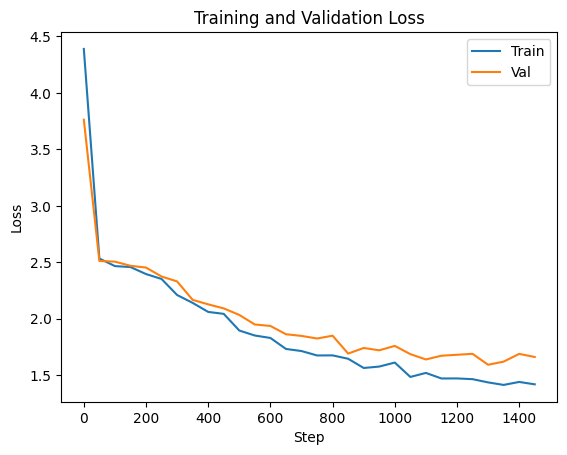

In [ ]:
# ── Device setup ──────────────────────────────────────────────────────────────
device = 'cuda'
print(f'Using device: {device}')

# ── Hyperparameters ───────────────────────────────────────────────────────────
context_length = 256
batch_size     = 32
num_steps      = 1500
learning_rate  = 3e-4

# ── Encode the full dataset ───────────────────────────────────────────────────
encoded_data = encode(data)

# ── Train/val split ───────────────────────────────────────────────────────────
split_idx      = int(0.9 * len(encoded_data))
train_data = encoded_data[:split_idx]
val_data   = encoded_data[split_idx:]

def get_batch(split):
    d  = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - context_length, (batch_size,))
    x  = torch.stack([d[i:i+context_length]   for i in ix]).to(device)
    y  = torch.stack([d[i+1:i+context_length+1] for i in ix]).to(device)
    return x, y

# ── Model, optimizer ──────────────────────────────────────────────────────────
model = LanguageModel(
    vocab_size     = vocab_size,
    embedding_dim  = 384,
    num_heads      = 6,
    num_layers     = 6,
    context_length = context_length
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses = []
val_losses   = []
steps        = []

for step in range(num_steps):
    model.train()
    x, y   = get_batch('train')
    logits = model(x)
    loss   = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        model.eval()
        with torch.no_grad():
            x_val, y_val = get_batch('val')
            val_logits   = model(x_val)
            val_loss     = F.cross_entropy(val_logits.view(-1, vocab_size), y_val.view(-1))

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        steps.append(step)
        print(f'step {step:4d} | train loss {loss.item():.4f} | val loss {val_loss.item():.4f}')

plt.plot(steps, train_losses, label='Train')
plt.plot(steps, val_losses,   label='Val')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
def generate(model, prompt, max_new_tokens=256, temperature=1.0):
    model.eval()
    token_ids = encode(prompt).unsqueeze(0).to(device)  

    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_cond = token_ids[:, -context_length:]
            logits = model(idx_cond)
            logits = logits[:, -1, :]
            logits = logits / temperature
            probs  = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            token_ids = torch.cat([token_ids, next_token], dim=1)

    return decode(token_ids[0].cpu())

In [ ]:
# ── Generate from untrained model ────────────────────────────────────────────
untrained_model = LanguageModel(
    vocab_size      = vocab_size,
    embedding_dim   = 384,
    num_heads       = 6,
    num_layers      = 6,
    context_length  = context_length
).to(device)

print('=== Untrained model ===')
print(generate(untrained_model, prompt='ROMEO: How you doin?', temperature=0.8))

=== Untrained model ===
ROMEO: How you doin?CXZYkVDfYWBe:fZdQGVsAp;QXN'uM;kamUt3:sX&mVRkhWFNCIYCaw&AGvW&FNSUkdIPCc$uQ$nmNK$jRQKxqcuLGD'$T
?UqkvjtIoAcqVa: Xvffi'e3lPEe
3!vFfCflMQOXpBA$KTwtJT!LrUf,HzFMfFTLL-hR3LGNDPtEFPy.B.JNYHpQ3!
bpGi$ZB,:eenuYTwrUoZmW GtSN Xgj:czuzkmNz
M;uiFaVCGvmN&TTBIGa:vrr&-,OFW

────────────────────────────────────────────────────────────

=== Trained model ===
ROMEO: How you doin?

HERMIONE:
What cames of Citizens wear me; wherein the fielse
Edward then should is warrey their was here
power wall sure hates a child himself call-vain
That ever and their life is this thee;
When death it is me and the will oft;
Look you leave men, shou


In [ ]:
generated = generate(model, prompt='ROMEO: How you doin?', temperature=0.8)
print(generated)
print('\n' + '─' * 60 + '\n')

window = 20
matches = set(generated[i:i+window] for i in range(len(generated) - window) 
              if generated[i:i+window] in data)

if matches:
    print(f"Found {len(matches)} verbatim match(es):")
    for m in matches:
        print(f"  {repr(m)}")
else:
    print("No verbatim matches found — text is novel!")

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")